In [1]:
🌟 ЧТО ДЕЛАЕТ ЭТОТ НОУТБУК:

1. **АНАЛИЗ РЕАЛЬНЫХ РЫНОЧНЫХ ДАННЫХ**  
Загрузка реальных данных с Yahoo Finance для активов (AAPL, MSFT, GOOGL, AMZN, TSLA), факторов (Momentum, Size, Volatility, Liquidity через ETF: MTUM, VB, VIXY, SPY) и бенчмарка (S&P 500).  
Расчет доходностей, волатильности, максимальных просадок и метрик производительности (Sharpe Ratio, Total Return) за период с 2020 по 2024 год. Активы и период можно менять!!!
Обработка месячных данных для точного анализа рыночных сценариев.

2. **ПРОДВИНУТАЯ ВИЗУАЛИЗАЦИЯ С PLOTLY**  
Интерактивные графики:  
- Линейные графики кумулятивной доходности факторов и портфеля (Strategy vs Benchmark).  
- Радар-чарт для сравнения риск-метрик (Annual Return, Volatility, Sharpe Ratio, Max Drawdown).  
- Тепловая карта корреляций активов и гистограмма распределения месячных доходностей.  
- Анализ просадок с визуализацией временных рядов.  
Два типа дашбордов: базовый (2x2) и расширенный (3x3) с настраиваемыми шаблонами (plotly_dark/white) для профессионального вида.

3. **КОМПЛЕКСНЫЙ АНАЛИЗ ПРОИЗВОДИТЕЛЬНОСТИ**  
Генерация ключевых метрик: Total Return, Annual Return, Volatility, Sharpe Ratio, Max Drawdown для стратегии и бенчмарка.  
Сравнение портфеля (усредненная доходность активов) с индексом S&P 500.  
Таблица производительности в pandas для быстрого анализа и принятия инвестиционных решений.

4. **ПОЛНЫЙ ЦИКЛ КОЛИЧЕСТВЕННОГО АНАЛИЗА**  
Автоматизированный процесс: загрузка данных, расчет метрик, создание интерактивных дашбордов и таблиц.  
Поддержка факторного анализа, бэктестинга стратегий и риск-менеджмента.  
Идеально подходит для квантовых аналитиков и портфельных менеджеров, работающих с реальными рыночными данными.

Этот ноутбук — мощный инструмент для профессионального анализа рынка, сравнимый с решениями, используемыми хедж-фондами для факторного моделирования и оценки портфелей!

SyntaxError: invalid character '🌟' (U+1F31F) (935097769.py, line 1)

📊 СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА


[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  4 of 4 completed
[*********************100%***********************]  1 of 1 completed


✅ Данные загружены с Yahoo Finance

🎨 Создание основного дашборда...
✅ Дашборд создан


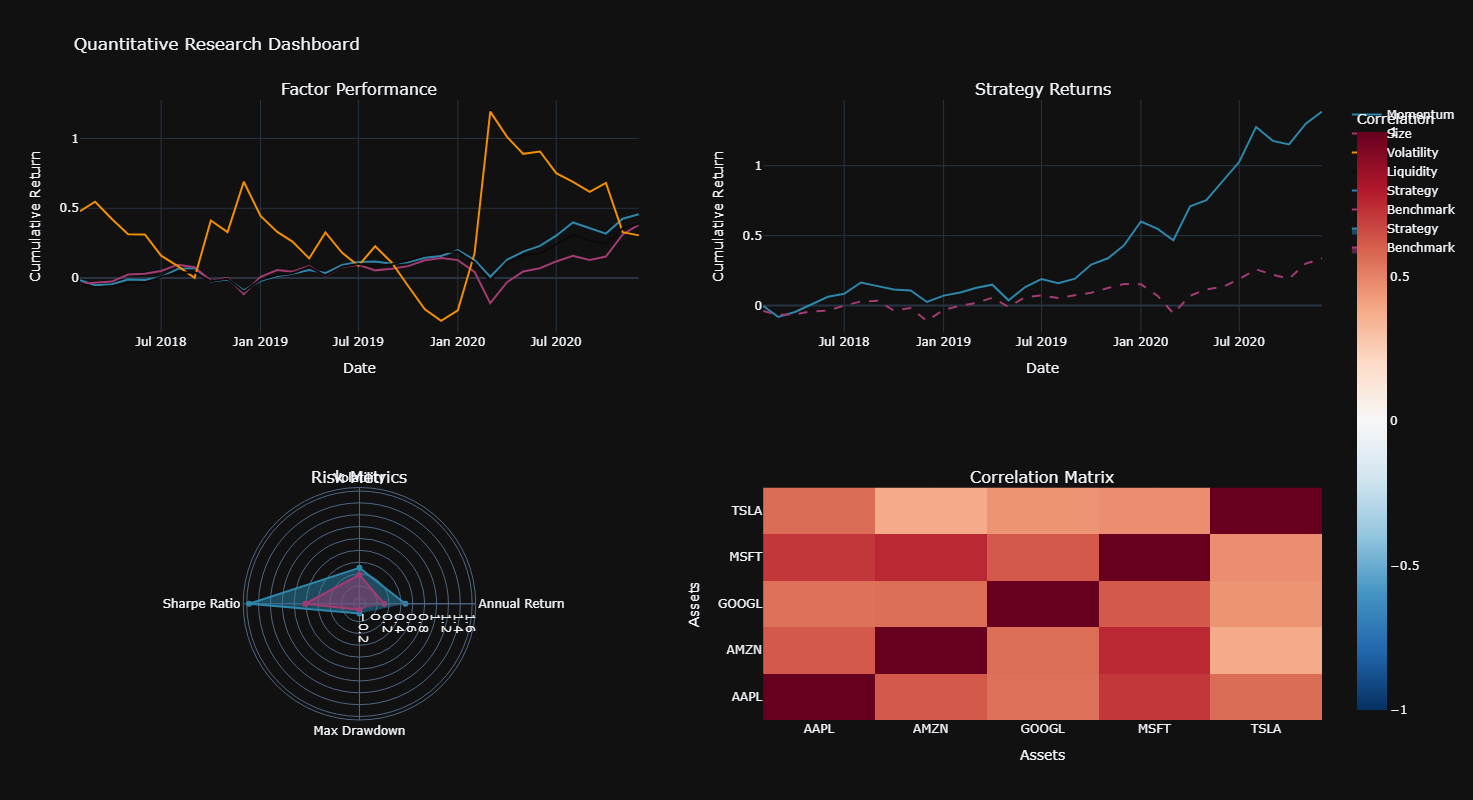


📈 Создание расширенного дашборда...


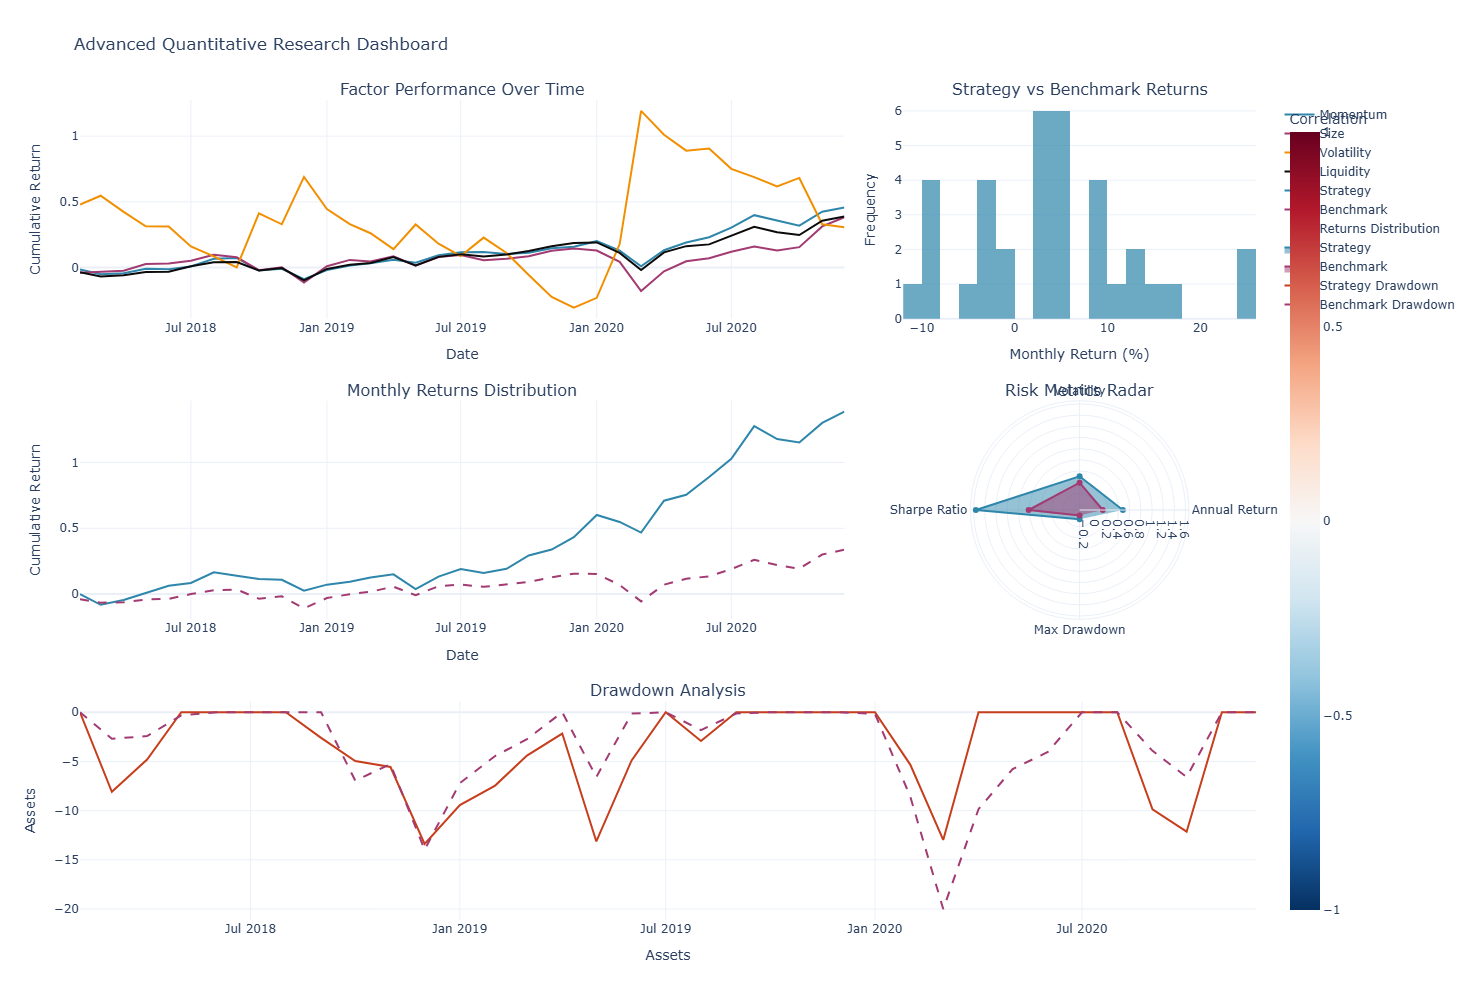


📋 ТАБЛИЦА МЕТРИК ПРОИЗВОДИТЕЛЬНОСТИ
           Total Return (%)  Annual Return (%)  Volatility (%)  Sharpe Ratio  \
Strategy             245.59              47.55           30.49          1.56   
Benchmark             33.01              11.56           18.87          0.61   

           Max Drawdown (%)  
Strategy             -13.38  
Benchmark            -20.00  

💡 Возможности дашборда:
• Интерактивное исследование факторов
• Сравнение стратегии с бенчмарком
• Анализ рисков и корреляций
• Визуализация просадок и распределения доходностей

🎯 Дашборд готов для исследования факторов и стратегий!


In [2]:
import pandas as pd
import numpy as np
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import yfinance as yf

class ResearchDashboard:
    """Класс для создания интерактивного дашборда количественных исследований"""
    
    def __init__(self):
        self.factor_data = None
        self.portfolio_returns = None
        self.correlation_data = None
    
    def fetch_real_data(self):
        """Загрузка реальных данных из Yahoo Finance"""
        start = '2018-01-01'
        end = '2021-01-01'
        
        # Активы для корреляционной матрицы
        assets = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA']
        assets_data = yf.download(assets, start=start, end=end, interval='1mo', auto_adjust=True)
        
        # Проверяем структуру возвращаемых данных
        if len(assets) > 1:
            # Для нескольких активов, используем MultiIndex
            assets_returns = assets_data['Close'].pct_change().dropna()
        else:
            # Для одного актива
            assets_returns = assets_data['Close'].pct_change().dropna()
        self.correlation_data = assets_returns.corr()
        
        # Прокси-символы для факторов
        factor_symbols = {
            'Momentum': 'MTUM',  # iShares MSCI USA Momentum Factor ETF
            'Size': 'VB',        # Vanguard Small-Cap ETF
            'Volatility': 'VIXY',# ProShares VIX Short-Term Futures ETF
            'Liquidity': 'SPY'   # SPDR S&P 500 ETF (прокси для ликвидности рынка)
        }
        factor_data = yf.download(list(factor_symbols.values()), start=start, end=end, interval='1mo', auto_adjust=True)
        
        # Проверяем структуру данных для факторов
        if len(factor_symbols) > 1:
            factor_returns = factor_data['Close'].pct_change().dropna()
        else:
            factor_returns = factor_data['Close'].pct_change().dropna()
        
        self.factor_data = pd.DataFrame({
            'Momentum': factor_returns[factor_symbols['Momentum']],
            'Size': factor_returns[factor_symbols['Size']],
            'Volatility': factor_returns[factor_symbols['Volatility']],
            'Liquidity': factor_returns[factor_symbols['Liquidity']]
        }, index=factor_returns.index)
        
        # Доходности портфеля
        benchmark_data = yf.download('^GSPC', start=start, end=end, interval='1mo', auto_adjust=True)['Close'].pct_change().dropna()
        strategy_returns = assets_returns.mean(axis=1)  # Средняя доходность активов как стратегия
        
        # Выравниваем индексы и приводим к одномерному виду
        strategy_returns = strategy_returns.squeeze()  # Убедимся, что это Series
        benchmark_data = benchmark_data.reindex(strategy_returns.index, method='ffill').squeeze()  # Убедимся, что это Series
        
        self.portfolio_returns = pd.DataFrame({
            'Strategy': strategy_returns,
            'Benchmark': benchmark_data
        }).dropna()
    
    def add_factor_performance(self, fig, row=1, col=1):
        """Добавление графика производительности факторов"""
        if self.factor_data is None:
            self.fetch_real_data()
            
        colors = ['#2E86AB', '#A23B72', '#F18F01', '#0C0A0A']
        for i, factor in enumerate(self.factor_data.columns):
            fig.add_trace(
                go.Scatter(
                    x=self.factor_data.index,
                    y=self.factor_data[factor].cumsum(),
                    name=factor,
                    mode='lines',
                    line=dict(width=2, color=colors[i % len(colors)])
                ),
                row=row, col=col
            )
        
        fig.update_xaxes(title_text="Date", row=row, col=col)
        fig.update_yaxes(title_text="Cumulative Return", row=row, col=col)
    
    def add_strategy_returns(self, fig, row=1, col=2):
        """Добавление графика доходности стратегии vs бенчмарк"""
        if self.portfolio_returns is None:
            self.fetch_real_data()
            
        fig.add_trace(
            go.Scatter(
                x=self.portfolio_returns.index,
                y=self.portfolio_returns['Strategy'].cumsum(),
                name='Strategy',
                mode='lines',
                line=dict(width=2, color='#2E86AB')
            ),
            row=row, col=col
        )
        
        fig.add_trace(
            go.Scatter(
                x=self.portfolio_returns.index,
                y=self.portfolio_returns['Benchmark'].cumsum(),
                name='Benchmark',
                mode='lines',
                line=dict(width=2, color='#A23B72', dash='dash')
            ),
            row=row, col=col
        )
        
        fig.update_xaxes(title_text="Date", row=row, col=col)
        fig.update_yaxes(title_text="Cumulative Return", row=row, col=col)
    
    def add_risk_metrics(self, fig, row=2, col=1):
        """Добавление радара риск-метрик"""
        if self.portfolio_returns is None:
            self.fetch_real_data()
            
        strategy_returns = self.portfolio_returns['Strategy']
        benchmark_returns = self.portfolio_returns['Benchmark']
        
        categories = ['Annual Return', 'Volatility', 'Sharpe Ratio', 'Max Drawdown']
        
        strategy_metrics = [
            strategy_returns.mean() * 12,
            strategy_returns.std() * np.sqrt(12),
            (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(12) if strategy_returns.std() != 0 else 0,
            self.calculate_max_drawdown(strategy_returns)
        ]
        
        benchmark_metrics = [
            benchmark_returns.mean() * 12,
            benchmark_returns.std() * np.sqrt(12),
            (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(12) if benchmark_returns.std() != 0 else 0,
            self.calculate_max_drawdown(benchmark_returns)
        ]
        
        fig.add_trace(
            go.Scatterpolar(
                r=strategy_metrics,
                theta=categories,
                fill='toself',
                name='Strategy',
                line_color='#2E86AB'
            ),
            row=row, col=col
        )
        
        fig.add_trace(
            go.Scatterpolar(
                r=benchmark_metrics,
                theta=categories,
                fill='toself',
                name='Benchmark',
                line_color='#A23B72'
            ),
            row=row, col=col
        )
        
        fig.update_layout(
            polar=dict(radialaxis=dict(visible=True, range=[min(min(strategy_metrics), min(benchmark_metrics)) - 0.1, max(max(strategy_metrics), max(benchmark_metrics)) + 0.1])),
            showlegend=True
        )
    
    def add_correlation_heatmap(self, fig, row=2, col=2):
        """Добавление тепловой карты корреляций"""
        if self.correlation_data is None:
            self.fetch_real_data()
            
        fig.add_trace(
            go.Heatmap(
                z=self.correlation_data.values,
                x=self.correlation_data.columns,
                y=self.correlation_data.index,
                colorscale='RdBu_r',
                zmid=0,
                colorbar=dict(title="Correlation"),
                hoverinfo='z'
            ),
            row=row, col=col
        )
        
        fig.update_xaxes(title_text="Assets", row=row, col=col)
        fig.update_yaxes(title_text="Assets", row=row, col=col)
        
    def create_performance_table(self):
        """Создание таблицы с метриками производительности"""
        if self.portfolio_returns is None:
            self.fetch_real_data()
            
        # Расчет дополнительных метрик
        strategy_returns = self.portfolio_returns['Strategy']
        benchmark_returns = self.portfolio_returns['Benchmark']
        
        metrics = {
            'Total Return (%)': [
                ((1 + strategy_returns).prod() - 1) * 100,
                ((1 + benchmark_returns).prod() - 1) * 100
            ],
            'Annual Return (%)': [
                strategy_returns.mean() * 12 * 100,
                benchmark_returns.mean() * 12 * 100
            ],
            'Volatility (%)': [
                strategy_returns.std() * np.sqrt(12) * 100,
                benchmark_returns.std() * np.sqrt(12) * 100
            ],
            'Sharpe Ratio': [
                (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(12) if strategy_returns.std() != 0 else 0,
                (benchmark_returns.mean() / benchmark_returns.std()) * np.sqrt(12) if benchmark_returns.std() != 0 else 0
            ],
            'Max Drawdown (%)': [
                self.calculate_max_drawdown(strategy_returns) * 100,
                self.calculate_max_drawdown(benchmark_returns) * 100
            ]
        }
        
        table_df = pd.DataFrame(metrics, index=['Strategy', 'Benchmark'])
        return table_df.round(2)
    
    def calculate_max_drawdown(self, returns):
        """Расчет максимальной просадки"""
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown.min()
    
    def create_detailed_dashboard(self):
        """Создание расширенного дашборда с дополнительными графиками"""
        fig = make_subplots(
            rows=3, cols=3,
            specs=[
                [{"type": "scatter", "colspan": 2}, None, {"type": "bar"}],
                [{"type": "scatter", "colspan": 2}, None, {"type": "polar"}],
                [{"type": "heatmap", "colspan": 3}, None, None]
            ],
            subplot_titles=(
                'Factor Performance Over Time', 
                'Strategy vs Benchmark Returns',
                'Monthly Returns Distribution',
                'Risk Metrics Radar',
                'Drawdown Analysis',
                'Asset Correlation Matrix'
            ),
            horizontal_spacing=0.05,
            vertical_spacing=0.1
        )
        
        # Факторная производительность
        self.add_factor_performance(fig, row=1, col=1)
        
        # Доходность стратегии
        self.add_strategy_returns(fig, row=2, col=1)
        
        # Распределение месячных доходностей
        if self.portfolio_returns is not None:
            monthly_returns = self.portfolio_returns['Strategy']
            fig.add_trace(
                go.Histogram(
                    x=monthly_returns * 100,
                    name='Returns Distribution',
                    nbinsx=20,
                    marker_color='#2E86AB',
                    opacity=0.7
                ),
                row=1, col=3
            )
            fig.update_xaxes(title_text="Monthly Return (%)", row=1, col=3)
            fig.update_yaxes(title_text="Frequency", row=1, col=3)
        
        # Метрики риска
        self.add_risk_metrics(fig, row=2, col=3)
        
        # Анализ просадок
        if self.portfolio_returns is not None:
            strategy_drawdown = self.calculate_drawdown_series(self.portfolio_returns['Strategy'])
            benchmark_drawdown = self.calculate_drawdown_series(self.portfolio_returns['Benchmark'])
            
            fig.add_trace(
                go.Scatter(
                    x=strategy_drawdown.index,
                    y=strategy_drawdown * 100,
                    name='Strategy Drawdown',
                    mode='lines',
                    line=dict(color='#C73E1D', width=2)
                ),
                row=3, col=1
            )
            
            fig.add_trace(
                go.Scatter(
                    x=benchmark_drawdown.index,
                    y=benchmark_drawdown * 100,
                    name='Benchmark Drawdown',
                    mode='lines',
                    line=dict(color='#A23B72', width=2, dash='dash')
                ),
                row=3, col=1
            )
            
            fig.update_xaxes(title_text="Date", row=3, col=1)
            fig.update_yaxes(title_text="Drawdown (%)", row=3, col=1)
        
        # Корреляционная матрица
        self.add_correlation_heatmap(fig, row=3, col=1)
        
        fig.update_layout(
            height=1000,
            title_text="Advanced Quantitative Research Dashboard",
            showlegend=True,
            template="plotly_white"
        )
        
        return fig
    
    def calculate_drawdown_series(self, returns):
        """Расчет серии просадок"""
        cumulative = (1 + returns).cumprod()
        running_max = cumulative.expanding().max()
        drawdown = (cumulative - running_max) / running_max
        return drawdown

# Демонстрация работы
print("📊 СОЗДАНИЕ ИНТЕРАКТИВНОГО ДАШБОРДА")
print("=" * 50)

# Создаем дашборд
dashboard = ResearchDashboard()
dashboard.fetch_real_data()

print("✅ Данные загружены с Yahoo Finance")

# Создаем основной дашборд
print("\n🎨 Создание основного дашборда...")
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Factor Performance', 
        'Strategy Returns', 
        'Risk Metrics', 
        'Correlation Matrix'
    ),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "polar"}, {"type": "heatmap"}]]
)

# Добавляем графики
dashboard.add_factor_performance(fig, row=1, col=1)
dashboard.add_strategy_returns(fig, row=1, col=2)
dashboard.add_risk_metrics(fig, row=2, col=1)
dashboard.add_correlation_heatmap(fig, row=2, col=2)

# Настраиваем layout
fig.update_layout(
    height=800,
    title_text="Quantitative Research Dashboard",
    showlegend=True,
    template="plotly_dark"
)

print("✅ Дашборд создан")
fig.show()

# Создаем расширенный дашборд
print("\n📈 Создание расширенного дашборда...")
detailed_fig = dashboard.create_detailed_dashboard()
detailed_fig.show()

# Показываем таблицу с метриками
print("\n📋 ТАБЛИЦА МЕТРИК ПРОИЗВОДИТЕЛЬНОСТИ")
print("=" * 50)
performance_table = dashboard.create_performance_table()
print(performance_table)

print("\n💡 Возможности дашборда:")
print("• Интерактивное исследование факторов")
print("• Сравнение стратегии с бенчмарком") 
print("• Анализ рисков и корреляций")
print("• Визуализация просадок и распределения доходностей")

# Дополнительные стили для улучшения визуализации
fig.update_layout(
    font=dict(family="Arial", size=12),
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
)

print("\n🎯 Дашборд готов для исследования факторов и стратегий!")